# Modelagem Preditiva com Machine Learning — Temperatura Brasil 2023

Este notebook aplica modelos de Machine Learning para prever a temperatura
com base em variáveis temporais e geográficas.

**Modelos utilizados:**
- Regressão Linear — modelo base (baseline)
- Random Forest Regressor — modelo avançado

**Métricas de avaliação:**
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² (Coeficiente de Determinação)

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from extractor import load_station_file
from processor import processar, ESTADO_REGIAO
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


## 1. Carregamento e preparação dos dados

In [2]:
# Carrega dados com UF e região
extract_dir = os.path.join('..', 'data', '2023')
arquivos = glob.glob(os.path.join(extract_dir, '*.CSV'))

frames = []
for filepath in arquivos:
    df_tmp = load_station_file(filepath)
    if not df_tmp.empty:
        nome = os.path.basename(filepath)
        partes = nome.split('_')
        df_tmp['UF'] = partes[2] if len(partes) > 2 else None
        frames.append(df_tmp)

df_raw = pd.concat(frames, ignore_index=True)
df, _ = processar(df_raw)

col_temp = 'TEMPERATURA_DO_AR_-_BULBO_SECO,_HORARIA_C'
col_precip = 'PRECIPITACAO'
col_umidade = 'UMIDADE_RELATIVA_DO_AR,_HORARIA_%'

df[col_temp] = pd.to_numeric(df[col_temp], errors='coerce')
df[col_precip] = pd.to_numeric(df[col_precip], errors='coerce')
df[col_umidade] = pd.to_numeric(df[col_umidade], errors='coerce')
df['REGIAO'] = df['UF'].map(ESTADO_REGIAO)

print(f"Total de registros: {len(df):,}")
print(df[['MES', 'UF', 'REGIAO', col_temp, col_precip, col_umidade]].head())

Iniciando processamento: 4,966,920 registros
Removidos 448,776 registros completamente vazios.
Colunas climáticas identificadas: {'precipitacao': 'PRECIPITACAO_TOTAL,_HORARIO_MM', 'temp_max': 'TEMPERATURA_MAXIMA_NA_HORA_ANT._AUT_C', 'temp_min': 'TEMPERATURA_MINIMA_NA_HORA_ANT._AUT_C'}
Processamento concluído: 4,518,144 registros
Total de registros: 4,518,144
   MES  UF        REGIAO  TEMPERATURA_DO_AR_-_BULBO_SECO,_HORARIA_C  \
0  1.0  DF  Centro-Oeste                                       20.1   
1  1.0  DF  Centro-Oeste                                       19.2   
2  1.0  DF  Centro-Oeste                                       19.3   
3  1.0  DF  Centro-Oeste                                       19.3   
4  1.0  DF  Centro-Oeste                                       19.7   

   PRECIPITACAO  UMIDADE_RELATIVA_DO_AR,_HORARIA_%  
0           0.0                               87.0  
1           0.0                               90.0  
2           0.0                               90.0  


## 2. Engenharia de features

Criamos variáveis preditoras a partir das informações disponíveis:
- Mês e hora do dia (sazonalidade e ciclo diário)
- Região do Brasil (fator geográfico)
- Umidade relativa e precipitação (variáveis climáticas correlacionadas)

In [3]:
# Extrai hora do dia
df['HORA'] = df['HORA_UTC'].str.extract(r'(\d{2})').astype(float)

# Codifica região como número
le = LabelEncoder()
df['REGIAO_COD'] = le.fit_transform(df['REGIAO'].fillna('Desconhecido'))

# Seleciona features e target
features = ['MES', 'HORA', 'REGIAO_COD', col_umidade, col_precip]
target = col_temp

# Remove linhas com qualquer valor nulo nas colunas selecionadas
df_ml = df[features + [target]].dropna()

# Filtra temperaturas impossíveis
df_ml = df_ml[df_ml[target].between(-20, 50)]

# Amostra 300k registros para agilizar o treino
df_ml = df_ml.sample(300000, random_state=42)

print(f"Registros para modelagem: {len(df_ml):,}")
print(f"\nFeatures: {features}")
print(f"Target: {target}")
print(df_ml.describe())

Registros para modelagem: 300,000

Features: ['MES', 'HORA', 'REGIAO_COD', 'UMIDADE_RELATIVA_DO_AR,_HORARIA_%', 'PRECIPITACAO']
Target: TEMPERATURA_DO_AR_-_BULBO_SECO,_HORARIA_C
                 MES           HORA     REGIAO_COD  \
count  300000.000000  300000.000000  300000.000000   
mean        6.505650      11.646553       2.137877   
std         3.452897       6.888617       1.401837   
min         1.000000       0.000000       0.000000   
25%         4.000000       6.000000       1.000000   
50%         7.000000      12.000000       2.000000   
75%        10.000000      18.000000       3.000000   
max        12.000000      23.000000       4.000000   

       UMIDADE_RELATIVA_DO_AR,_HORARIA_%   PRECIPITACAO  \
count                      300000.000000  300000.000000   
mean                           72.018770       0.157503   
std                            20.297339       1.291341   
min                             9.000000       0.000000   
25%                            58.000000

## 3. Divisão treino e teste

In [4]:
X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {len(X_train):,} registros")
print(f"Teste:  {len(X_test):,} registros")

Treino: 240,000 registros
Teste:  60,000 registros


## 4. Modelo 1 — Regressão Linear (baseline)

In [5]:
# Treina o modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Previsões
y_pred_lr = lr.predict(X_test)

# Métricas
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Regressão Linear:")
print(f"  RMSE: {rmse_lr:.2f}°C")
print(f"  MAE:  {mae_lr:.2f}°C")
print(f"  R²:   {r2_lr:.4f}")

Regressão Linear:
  RMSE: 3.69°C
  MAE:  2.92°C
  R²:   0.5544


## 5. Modelo 2 — Random Forest Regressor

In [6]:
# Treina o modelo
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Previsões
y_pred_rf = rf.predict(X_test)

# Métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print(f"  RMSE: {rmse_rf:.2f}°C")
print(f"  MAE:  {mae_rf:.2f}°C")
print(f"  R²:   {r2_rf:.4f}")

Random Forest:
  RMSE: 3.06°C
  MAE:  2.34°C
  R²:   0.6919


## 6. Comparativo entre os modelos

          Modelo  RMSE (°C)  MAE (°C)       R²
Regressão Linear   3.685107  2.915337 0.554363
   Random Forest   3.064278  2.341322 0.691868


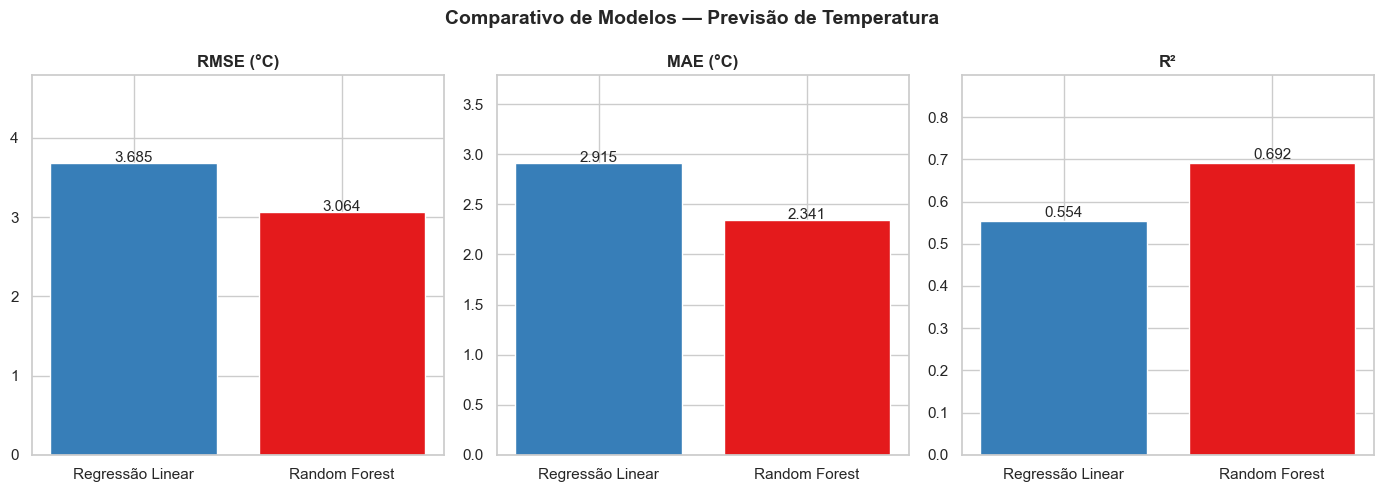

Gráfico salvo!


In [7]:
# Tabela comparativa
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest'],
    'RMSE (°C)': [rmse_lr, rmse_rf],
    'MAE (°C)': [mae_lr, mae_rf],
    'R²': [r2_lr, r2_rf]
})
print(resultados.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metricas = ['RMSE (°C)', 'MAE (°C)', 'R²']
cores_mod = ['#377eb8', '#e41a1c']

for ax, metrica in zip(axes, metricas):
    bars = ax.bar(resultados['Modelo'], resultados[metrica], color=cores_mod)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylim(0, max(resultados[metrica]) * 1.3)
    for bar, val in zip(bars, resultados[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=11)

fig.suptitle('Comparativo de Modelos — Previsão de Temperatura', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/comparativo_modelos.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 7. Valores reais vs previstos

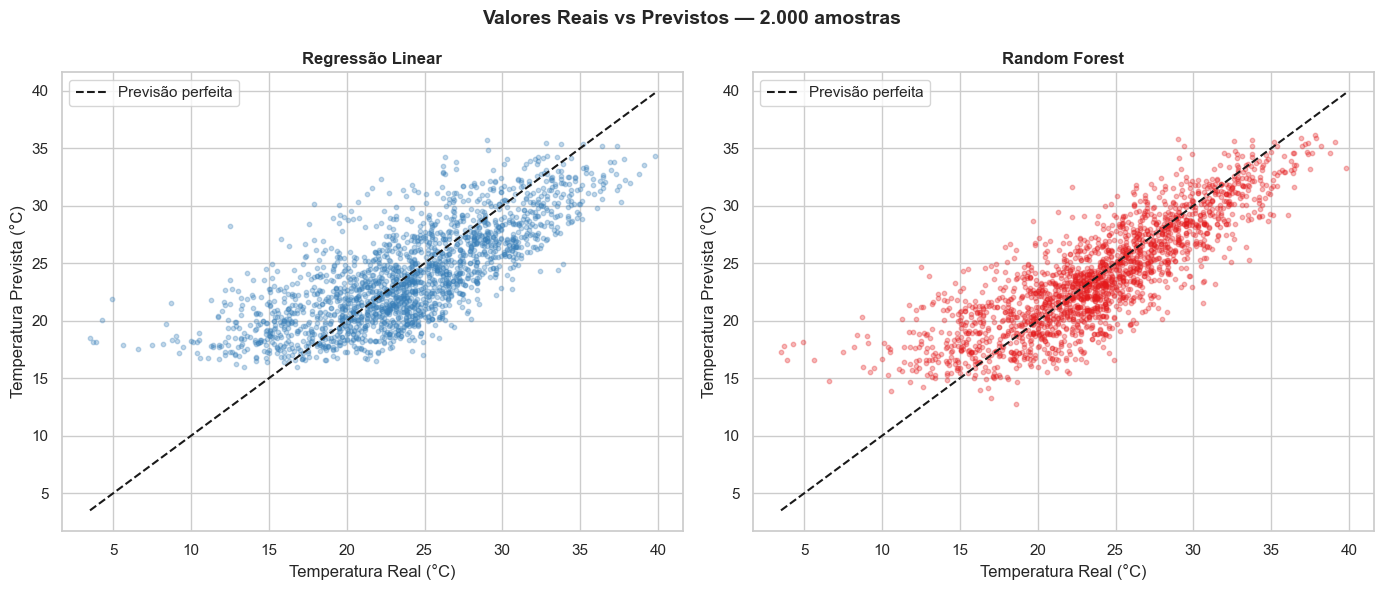

Gráfico salvo!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Amostra para visualização
idx = np.random.choice(len(y_test), 2000, replace=False)
y_test_sample = y_test.iloc[idx]
y_pred_lr_sample = y_pred_lr[idx]
y_pred_rf_sample = y_pred_rf[idx]

for ax, y_pred, titulo, cor in zip(
    axes,
    [y_pred_lr_sample, y_pred_rf_sample],
    ['Regressão Linear', 'Random Forest'],
    ['#377eb8', '#e41a1c']
):
    ax.scatter(y_test_sample, y_pred, alpha=0.3, s=10, color=cor)
    ax.plot([y_test_sample.min(), y_test_sample.max()],
            [y_test_sample.min(), y_test_sample.max()],
            'k--', linewidth=1.5, label='Previsão perfeita')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Temperatura Real (°C)')
    ax.set_ylabel('Temperatura Prevista (°C)')
    ax.legend()

fig.suptitle('Valores Reais vs Previstos — 2.000 amostras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/real_vs_previsto.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 8. Importância das features — Random Forest

C:\Users\ingri\AppData\Local\Temp\ipykernel_7784\2356605621.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([labels.get(f, f) for f in importancias['Feature']])


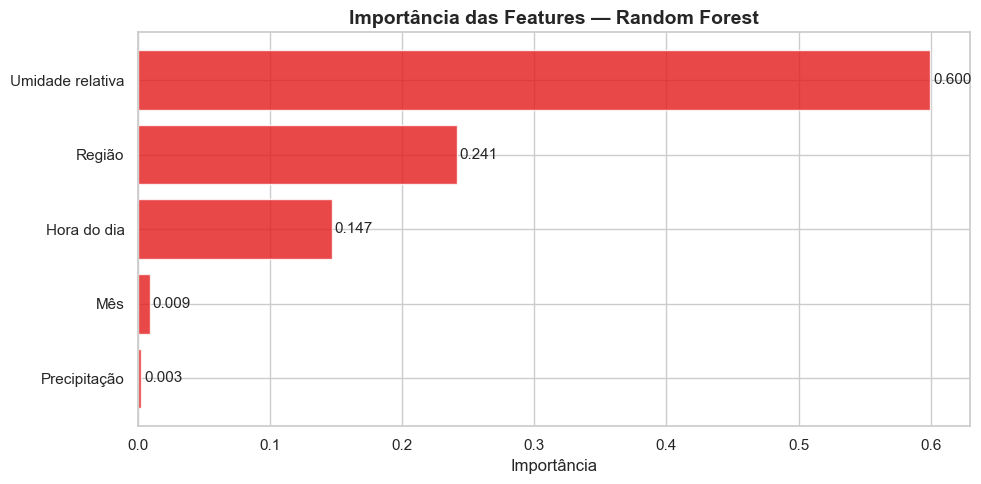

Gráfico salvo!


In [9]:
# Importância de cada variável no Random Forest
importancias = pd.DataFrame({
    'Feature': features,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importancias['Feature'], importancias['Importancia'],
               color='#e41a1c', alpha=0.8)

for bar, val in zip(bars, importancias['Importancia']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11)

ax.set_title('Importância das Features — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')
labels = {
    'MES': 'Mês',
    'HORA': 'Hora do dia',
    'REGIAO_COD': 'Região',
    'UMIDADE_RELATIVA_DO_AR,_HORARIA_%': 'Umidade relativa',
    'PRECIPITACAO': 'Precipitação'
}
ax.set_yticklabels([labels.get(f, f) for f in importancias['Feature']])
plt.tight_layout()
plt.savefig('../data/importancia_features.png', dpi=150)
plt.show()
print("Gráfico salvo!")

## 9. Conclusões

### Resultados dos modelos

| Modelo | RMSE | MAE | R² |
|---|---|---|---|
| Regressão Linear | 3.69°C | 2.92°C | 0.55 |
| Random Forest | 3.06°C | 2.34°C | 0.69 |

- O **Random Forest superou a Regressão Linear** em todas as métricas
- O erro médio de **2.34°C** é razoável considerando a diversidade climática do Brasil
- A feature mais importante foi a **umidade relativa** (60%), seguida da região (24%)

### Interpretação
A umidade relativa ser a variável mais preditiva confirma a forte relação inversa
entre umidade e temperatura — quanto mais seco, mais quente. Isso é especialmente
visível no Nordeste e Centro-Oeste durante o período de seca.

### Próximos passos
- Adicionar latitude e longitude como features geográficas
- Testar modelos mais avançados: XGBoost, LightGBM
- Construir modelo por região para maior precisão